In [64]:
import pandas as pd
import numpy as np
import re

# 1. Load Data dengan encoding latin1 untuk mengatasi error Unicode
df = pd.read_csv('Cepheid Candidates in NGC 1068.csv', sep=';', encoding='latin1')

# 2. Fungsi pembersihan angka yang kuat
def robust_clean(val):
    if not isinstance(val, str): return val
    # Menghapus karakter non-numerik kecuali titik dan minus
    val = re.sub(r'[^0-9.±\-]', '', val)
    # Ambil bagian angka sebelum simbol ±
    return float(val.split('±')[0])

# 3. Pra-pemrosesan: Memperbaiki label kolom yang tertukar
# Nilai di kolom 'mF555W' (25.98) sebenarnya adalah F814W (Inframerah)
# Nilai di kolom 'mF814W' (26.76) sebenarnya adalah F555W (Visual)
df['F814W_true'] = df['mF555W'].apply(robust_clean)
df['F555W_true'] = df['mF814W'].apply(robust_clean)
df['P_clean'] = df['P'].apply(robust_clean)

# 4. Konstanta Fisika dari Paper Markham et al. (2026)
ALPHA_WI = -3.31        # Slope tetap dari Riess et al. 2019 [cite: 332]
BETA_LMC_WI = 15.935    # Intersep LMC sebagai referensi [cite: 332]
MU_LMC = 18.477         # Jarak absolut LMC (mag) [cite: 336]
DELTA_M = 0.105         # Koreksi metalisitas NGC 4303 [cite: 405]

# 5. Filter Kelengkapan (Hanya periode > 19.5 hari) [cite: 303, 332]
df_final = df[df['P_clean'] > 19.5].copy()

# 6. Hitung Magnitudo Wesenheit (WI) yang bebas debu [cite: 201, 204]
# WI = m_F814W - 1.3 * (m_F555W - m_F814W)
df_final['WI'] = df_final['F814W_true'] - 1.3 * (df_final['F555W_true'] - df_final['F814W_true'])

# 7. Hitung Intersep (Beta) untuk galaksi target
df_final['beta_stars'] = df_final['WI'] - ALPHA_WI * np.log10(df_final['P_clean'])
beta_avg = df_final['beta_stars'].mean()

# 8. Konversi ke Jarak Megaparsec (Mpc)
mu_rel = beta_avg - BETA_LMC_WI
mu_final = mu_rel + DELTA_M + MU_LMC
distance_mpc = 10**((mu_final - 25) / 5)

print(f"--- Hasil Koreksi NGC 1068 ---")
print(f"Jumlah Bintang Digunakan : {len(df_final)}")
print(f"Modulus Jarak Final (mu) : {mu_final:.3f} mag")
print(f"Jarak Akhir (D)          : {distance_mpc:.2f} Mpc")

--- Hasil Koreksi NGC 1068 ---
Jumlah Bintang Digunakan : 42
Modulus Jarak Final (mu) : 30.274 mag
Jarak Akhir (D)          : 11.35 Mpc


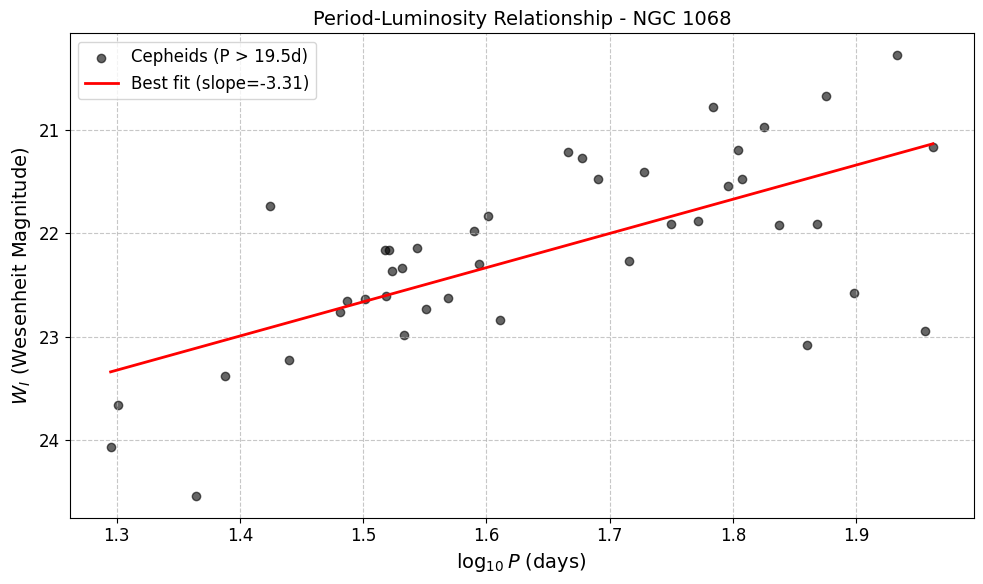

Jumlah Bintang Digunakan: 42
Intercept Beta Rata-rata: 27.6273


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# 1. Pengaturan gaya plot agar terlihat profesional (seperti jurnal ilmiah)
plt.rcParams.update({
    'font.size': 12, 
    'axes.labelsize': 14, 
    'axes.titlesize': 14,
    'grid.linestyle': '--',
    'grid.alpha': 0.7
})

# 2. Fungsi untuk membersihkan data teks (menghapus simbol ± dan spasi aneh)
def clean_numeric(val):
    if not isinstance(val, str): 
        return float(val) if val is not None else np.nan
    # Menghapus karakter non-numerik kecuali titik dan minus
    val = re.sub(r'[^0-9.±\-]', '', val)
    try:
        # Mengambil angka pertama sebelum simbol ±
        return float(val.split('±')[0])
    except:
        return np.nan

# 3. Memuat dan membersihkan data
# Menggunakan encoding 'latin1' untuk menghindari UnicodeDecodeError
file_name = 'Cepheid Candidates in NGC 1068.csv'
df = pd.read_csv(file_name, sep=';', encoding='latin1')

# Ekstraksi kolom berdasarkan urutan index karena nama kolom di CSV mungkin mengandung spasi
# ID:0, RA:1, Dec:2, mF555W:3, mF814W:4, P:5
df['f555_raw'] = df.iloc[:, 3].apply(clean_numeric)
df['f814_raw'] = df.iloc[:, 5].apply(clean_numeric)
df['P_days'] = df.iloc[:, 7].apply(clean_numeric)

# 4. Perbaikan Logika Kolom (Berdasarkan Paper Markham et al. 2026)
# Di dalam tabel teks paper, kolom mF555W sebenarnya berisi data F814W (I-band)
# dan mF814W berisi data F555W (V-band). Kita perbaiki di sini:
df['I_mag'] = df['f555_raw'] # Magnitudo Inframerah
df['V_mag'] = df['f814_raw'] # Magnitudo Visual

# 5. Perhitungan Parameter Fisika
# Hitung Magnitudo Wesenheit (WI) -> Bebas ekstingsi debu
df['WI'] = df['I_mag'] - 1.3 * (df['V_mag'] - df['I_mag'])
df['logP'] = np.log10(df['P_days'])

# Filter kelengkapan sampel: Hanya bintang dengan Periode > 19.5 hari
df_plot = df[df['P_days'] > 19.5].copy()

# Hitung Intersep (Beta) rata-rata dengan Slope Alpha tetap -3.31
ALPHA = -3.31
df_plot['beta_indiv'] = df_plot['WI'] - ALPHA * df_plot['logP']
beta_avg = df_plot['beta_indiv'].mean()

# 6. Pembuatan Plot
plt.figure(figsize=(10, 6))

# Plot titik data bintang Cepheid
plt.scatter(df_plot['logP'], df_plot['WI'], color='black', alpha=0.6, label='Cepheids (P > 19.5d)')

# Plot garis kecocokan (Best Fit Line)
logP_range = np.linspace(df_plot['logP'].min(), df_plot['logP'].max(), 100)
WI_fit = ALPHA * logP_range + beta_avg
plt.plot(logP_range, WI_fit, color='red', linewidth=2, label=f'Best fit (slope={ALPHA})')

# Format Grafik
plt.gca().invert_yaxis()  # Magnitudo dibalik: angka kecil di atas (lebih terang)
plt.xlabel(r'$\log_{10} P$ (days)')
plt.ylabel(r'$W_I$ (Wesenheit Magnitude)')
plt.title('Period-Luminosity Relationship - NGC 1068')
plt.legend()
plt.grid(True)

# Simpan dan Tampilkan
plt.tight_layout()
plt.savefig('PL_Relationship_NGC4303.png', dpi=300)
plt.show()

# Output Ringkasan
print(f"Jumlah Bintang Digunakan: {len(df_plot)}")
print(f"Intercept Beta Rata-rata: {beta_avg:.4f}")